목표 : AI Agent 개발을 위한 LangChian, LangGraph 실습하기

목적 : 도로교통법을 해석해서 질문에 답해주기


주요기능
1. 사용자가 자동차 운전자 사이의 다툼, 사고 등 도로교통법에 관련된 질문을 하면 도로교통법 법률과 판례, 사례를 근거로 상황을 해석해서 답변한다.
2. 사용자가 도로교통법과 무관한 질문을 하면 도로교통법에 관한 질문을 해달라고 답변한다.
3. 필요하면 사례를 웹 검색하여 링크를 제공한다.


부가기능
1. 사용자별 세션 구분을 위한 id 사용한다 (사용자 최대 3)
2. 각 세션 별 context 유지를 위한 메모리 사용한다


Tool Calling
1. RAG
2. DuckDuckGo websearch


Flow
1. 질문을 input() 으로 입력 받음.
2. 질문과 유사도가 높은 법률을 '도로교통법_법률_제21246호.pdf' 에서 검색하여 법률 번호 확인.
3. 단순 법률 해석 질문이면 검색된 법률 번호 함께 내용 일반인 대상으로 재해석하여 설명을 출력.
4. 법률 위반인지 판단이 필요하면 확인한 법률 번호를 '판례목록.txt' 에서 찾아서 결과를 해석.
5. '판례목록.txt' 에 관련 내용이 없다면 웹 에서 유사 사례를 검색.
6. 판례, 유사 사례가 없다고 판단되면 '판례 및 사례를 찾을 수 없습니다.' 출력.


문서 폴더 경로 : .\simple_lang1_dataset\

---
## PoC 구현 가이드 (입문자용)
아래 셀을 **위에서부터 순서대로** 실행하세요.

```
질문 입력
   ↓
관련성 판단 (triage)
   ├─ 관련 → 법률 RAG 검색 → (아래 유형 분류로)
   ├─ 반복·모호·겉보기 무관 + 이전 문맥으로 추정 가능 → 역질문(clarify) → 종료
   │         └─ (다음 사용자 답변) → triage 재실행 → retrieve / reject
   └─ 역질문 불가 기준에 해당 → 거절(reject) → 종료

질문 유형 분류 (retrieve 이후)
   ├─ 단순 해석 → 법률 설명 → 종료
   └─ 위반 판단 → 판례목록 검색
                   ├─ 있음 → 판례 해설 → 종료
                   └─ 없음 → 웹 검색
                               ├─ 있음 → 사례+링크 → 종료
                               └─ 없음 → "판례 및 사례를 찾을 수 없습니다."
```


### Step 0. 패키지 설치 (처음 1회만)
* day4 RAG / day15 LangGraph / day16 Chroma·웹검색에서 쓰던 패키지입니다.

In [ ]:
# 필요한 패키지 설치 (이미 설치되어 있으면 건너뛰어도 됩니다)
#%pip install -q langchain langchain-openai langchain-community langchain-chroma langchain-text-splitters langgraph pypdf chromadb ddgs python-dotenv

Note: you may need to restart the kernel to use updated packages.


### Step 1. 환경 변수 · 경로 설정
* `.env`의 `OPENAI_API_KEY`를 읽고, 데이터/Chroma 저장 경로를 정합니다.

In [23]:
import os
from pathlib import Path

from dotenv import load_dotenv

# 프로젝트 루트(.env)와 현재 폴더 모두 시도
load_dotenv()
load_dotenv(Path.cwd().parent / '.env')

OPENAI_API_KEY = os.getenv('OPENAI_API_KEY')
assert OPENAI_API_KEY, 'OPENAI_API_KEY가 없습니다. .env 파일을 확인하세요.'

# 이 노트북이 있는 폴더 기준 경로
BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / 'simple_lang1_dataset'
PDF_PATH = DATA_DIR / '도로교통법_법률_제21246호.pdf'
CASE_PATH = DATA_DIR / '판례목록.txt'
CHROMA_DIR = BASE_DIR / 'chroma_traffic_law'  # 임베딩 결과 저장 폴더

print('BASE_DIR :', BASE_DIR)
print('PDF      :', PDF_PATH.exists(), PDF_PATH.name)
print('CASE     :', CASE_PATH.exists(), CASE_PATH.name)

BASE_DIR : d:\Project\AI_class\doitmyself
PDF      : True 도로교통법_법률_제21246호.pdf
CASE     : True 판례목록.txt


### Step 2. LLM 준비
* 답변 생성·분류에 사용할 Chat 모델을 만듭니다. (day14/15와 동일 패턴)

In [24]:
from langchain_openai import ChatOpenAI

# temperature=0 → 분류/판단이 비교적 안정적
llm = ChatOpenAI(model='gpt-4o-mini', temperature=0, api_key=OPENAI_API_KEY)
print('LLM ready:', llm.model_name)

LLM ready: gpt-4o-mini


### Step 3. RAG용 벡터스토어 만들기 (Tool 1)
* day4 / day16 패턴: **PDF 로드 → 청크 분할 → 임베딩 → Chroma 저장**
* 한 번 만들면 `CHROMA_DIR`에 저장되어, 다음 실행부터는 바로 불러옵니다.

In [25]:
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_openai import OpenAIEmbeddings
from langchain_chroma import Chroma


def build_or_load_vectorstore():
    """도로교통법 PDF를 ChromaDB로 만들거나, 이미 있으면 불러옵니다."""
    embedding = OpenAIEmbeddings(
        model='text-embedding-3-small',
        api_key=OPENAI_API_KEY,
    )

    # 이미 저장본이 있으면 재사용 (시간·비용 절약)
    if CHROMA_DIR.exists() and any(CHROMA_DIR.iterdir()):
        print('기존 Chroma 로드:', CHROMA_DIR)
        return Chroma(
            persist_directory=str(CHROMA_DIR),
            embedding_function=embedding,
        )

    print('PDF → Chroma 새로 구축 중...')
    pages = PyPDFLoader(str(PDF_PATH)).load()

    # 긴 법률 문서를 검색하기 쉬운 작은 덩어리로 자름
    splitter = RecursiveCharacterTextSplitter(chunk_size=800, chunk_overlap=120)
    chunks = splitter.split_documents(pages)

    store = Chroma.from_documents(
        documents=chunks,
        embedding=embedding,
        persist_directory=str(CHROMA_DIR),
        collection_metadata={'hnsw:space': 'cosine'},
    )
    print(f'완료: pages={len(pages)}, chunks={len(chunks)}')
    return store


vectorstore = build_or_load_vectorstore()

# 간단 테스트: 유사 조문 1개만 확인
demo = vectorstore.similarity_search('음주운전 처벌', k=1)
print('--- 검색 샘플 ---')
print(demo[0].page_content[:300])

기존 Chroma 로드: d:\Project\AI_class\doitmyself\chroma_traffic_law
--- 검색 샘플 ---
법제처                                                            50                                                       국가법령정보센터
도로교통법
4. 제111조를 위반하여 수강료등의 반환 등 교육생 보호를 위하여 필요한 조치를 하지 아니한 사람
5. 제112조를 위반하여 학원이나 전문학원의 휴원 또는 폐원 신고를 하지 아니한 사람
6. 제115조제1항에 따른 간판이나 그 밖의 표지물 제거, 시설물의 설치 또는 게시문의 부착을 거부ㆍ방해 


### Step 4. 판례목록 검색 함수
* `판례목록.txt`에서 키워드(예: 음주운전, 무면허)가 들어간 줄을 찾습니다.
* 복잡한 DB 없이 **텍스트 파일 + 포함 여부**만 사용합니다.

In [26]:
def load_case_lines() -> list[str]:
    """판례목록.txt 전체를 줄 단위 리스트로 읽습니다."""
    text = CASE_PATH.read_text(encoding='utf-8')
    return [line.strip() for line in text.splitlines() if line.strip()]


CASE_LINES = load_case_lines()
print('판례 줄 수:', len(CASE_LINES))


def search_cases(keywords: list[str], top_n: int = 5) -> list[str]:
    """키워드가 하나라도 들어간 판례 줄을 최대 top_n개 반환합니다."""
    hits = []
    for line in CASE_LINES:
        # 키워드 중 하나라도 포함되면 후보
        if any(k and k in line for k in keywords):
            hits.append(line)
        if len(hits) >= top_n:
            break
    return hits


# 간단 테스트
print('--- 음주운전 판례 샘플 ---')
for h in search_cases(['음주운전'], top_n=3):
    print(h[:120], '...')

판례 줄 수: 1368
--- 음주운전 판례 샘플 ---
1. 폭력행위등처벌에관한법률위반(공동상해)·공무집행방해·도로교통법위반(음주운전)·도로교통법위반(무면허운전) 2017도17762 대법원 2017. 12. 28. ...
2. 사기·도로교통법위반(음주운전)·도로교통법위반(음주운전)·도로교통법위반(무면허운전)·도로교통법위반(무면허운전)·도로교통법위반(음주운전)·도로교통법위반(무면허운전)·도로교통법위반(음주운전)·도로교통법위반(무면허운전 ...
3. 사기·전자금융거래법위반·교통사고처리특례법위반(치상)·도로교통법위반(무면허운전)·도로교통법위반(음주운전) 2020도16420 대법원 2022. 12. 22. ...


### Step 5. 웹 검색 함수 (Tool 2)
* day16과 같이 `ddgs`(DuckDuckGo)로 유사 사례를 찾습니다.
* 결과에는 **제목·요약·링크**가 포함됩니다.

In [27]:
from ddgs import DDGS
from ddgs.exceptions import DDGSException


def web_search_cases(query: str, max_results: int = 3) -> list[dict]:
    """질문에 대한 웹 검색 결과(dict 리스트)를 반환합니다. 실패 시 빈 리스트."""
    try:
        with DDGS() as ddgs:
            # 도로교통 사례에 더 잘 맞게 검색어를 조금 보강
            q = f'도로교통법 {query} 판례 OR 사례'
            return list(ddgs.text(q, max_results=max_results))
    except DDGSException as e:
        print('웹 검색 실패:', e)
        return []


# 간단 테스트 (네트워크 필요)
demo_web = web_search_cases('신호위반 사고 과실', max_results=2)
print('웹 결과 개수:', len(demo_web))
if demo_web:
    print(demo_web[0])

웹 결과 개수: 2
{'title': '[신호위반교통사고 벌금형] 12대중과실교통사고 피의자, 벌금형 종결 ...', 'href': 'https://www.daeryunlaw.com/success_template/911', 'body': '의뢰인은 신호위반교통사고 발생시켰으며 상대방은 갈비뼈 3개가 골절되었습니다. 의뢰인은 12대중과실교통사고로 경찰조사 전, 신속하게 법무법인 대륜을 찾아오셨습니다.'}


### Step 6. Agent State 정의
* LangGraph에서 노드들이 공유하는 **한 장의 메모장**입니다.
* 노드가 `return {'필드': 값}` 하면 State가 갱신됩니다. (day15 패턴)
* `triage_route`: triage 후 분기 (`retrieve` / `clarify` / `reject`)
* `history_text` / `awaiting_clarify`: 역질문·문맥 추론용


In [28]:
from typing import Literal
from pydantic import BaseModel, Field


class AgentState(BaseModel):
    """도로교통법 Agent가 질문 하나도 처리하는 동안 들고 다니는 상태."""
    session_id: str = 'user1'          # 사용자 구분 (최대 3명)
    question: str = ''                 # 이번 질문
    history_text: str = ''             # 이전 대화 텍스트 (문맥 추론용)
    awaiting_clarify: bool = False     # 직전 AI 역질문에 대한 사용자 답변인가?
    is_traffic: bool = False           # 도로교통 관련 질문인가?
    triage_route: Literal['retrieve', 'clarify', 'reject'] = 'reject'
    law_docs: list[str] = Field(default_factory=list)  # RAG로 찾은 법률 조각
    need_case: bool = False            # 위반 판단(판례)이 필요한가?
    case_hits: list[str] = Field(default_factory=list)  # 판례목록 검색 결과
    web_hits: list[dict] = Field(default_factory=list)  # 웹 검색 결과
    answer: str = ''                   # 최종 답변
    source: Literal['reject', 'clarify', 'law', 'case', 'web', 'none', ''] = ''


print(AgentState(question='테스트'))


session_id='user1' question='테스트' history_text='' awaiting_clarify=False is_traffic=False triage_route='reject' law_docs=[] need_case=False case_hits=[] web_hits=[] answer='' source=''


### Step 7. 노드 함수들
* 각 노드는 **한 가지 일만** 하고, 바꾼 필드만 dict로 반환합니다.
* day15 Node / day16 retrieve·relevance·web_search와 같은 방식입니다.
* triage는 `retrieve` / `clarify`(역질문) / `reject` 중 하나를 고릅니다.


In [40]:
# 역질문을 만들기 어려운 상태 (= 바로 reject) 판단 기준
HARD_TO_CLARIFY_RULES = """
[역질문 불가 기준 — 하나라도 해당하면 REJECT]
1) 이전 대화(history)가 비어 있다.
2) 이전 대화에 도로교통/운전/사고/신호/과실/처벌 등 관련 내용이 전혀 없다.
3) 현재 입력이 의미를 파악하기 어렵다 (빈 내용, 이모지만, 의미 없는 문자열, 1글자 수준).
4) 이전 대화와 현재 입력 사이에 연결 가능한 도로교통 주제 후보가 없다.
5) 직전 AI 역질문에 대한 답변인데도, 도로교통 관련 의도로 정리할 수 없다.
"""


def _parse_route(text: str) -> str:
    """LLM 출력에서 RETRIEVE/CLARIFY/REJECT를 뽑습니다."""
    raw = (text or '').strip().upper()
    for key in ('RETRIEVE', 'CLARIFY', 'REJECT'):
        if key in raw:
            return key.lower()
    return 'reject'


def triage_node(state: AgentState) -> dict:
    """역할: 관련 여부 판단. 무관/모호해도 문맥으로 추정 가능하면 clarify."""
    history = state.history_text.strip() or '(없음)'

    # 역질문에 대한 답변 턴: retrieve / reject 만 (clarify 재진입 방지)
    if state.awaiting_clarify:
        prompt = (
            '당신은 도로교통법 Agent의 triage입니다.\n'
            '직전 AI가 역질문을 했고, 아래는 사용자의 답변입니다.\n'
            '도로교통법/운전/사고/과실/처벌 관련으로 해석 가능하면 ROUTE=RETRIEVE,\n'
            '아니면 ROUTE=REJECT 만 한 줄로 출력하세요.\n\n'
            f'{HARD_TO_CLARIFY_RULES}\n\n'
            f'이전 대화:\n{history}\n\n'
            f'사용자 답변(현재 입력): {state.question}'
        )
        verdict = llm.invoke(prompt).content
        route = _parse_route(verdict)
        if route == 'clarify':
            route = 'reject'
        ok = route == 'retrieve'
        print('[triage/awaiting_clarify]', verdict.strip(), '→', route)
        return {'is_traffic': ok, 'triage_route': route}

    prompt = (
        '당신은 도로교통법 Agent의 triage입니다.\n'
        '출력은 반드시 한 줄로: ROUTE=RETRIEVE 또는 ROUTE=CLARIFY 또는 ROUTE=REJECT\n\n'
        '[판단 규칙]\n'
        '1) 현재 입력이 명백히 도로교통/운전/사고/법규 관련이면 RETRIEVE\n'
        '2) 과거 질문 반복, 짧거나 모호, 겉보기 무관해도 '
        '이전 대화 문맥으로 도로교통 관련 의도를 추정할 수 있으면 CLARIFY\n'
        '3) 아래 역질문 불가 기준에 해당하면 REJECT (바로 거절)\n\n'
        f'{HARD_TO_CLARIFY_RULES}\n\n'
        f'이전 대화:\n{history}\n\n'
        f'현재 질문: {state.question}'
    )
    verdict = llm.invoke(prompt).content
    route = _parse_route(verdict)
    ok = route == 'retrieve'
    print('[triage]', verdict.strip(), '→', route)
    return {'is_traffic': ok, 'triage_route': route}


def clarify_node(state: AgentState) -> dict:
    """역할: 이전 문맥에서 추정한 도로교통 주제로 역질문 1~2문장 생성."""
    history = state.history_text.strip() or '(없음)'
    prompt = (
        '당신은 도로교통법 상담 Agent입니다.\n'
        '사용자의 입력이 모호하거나 반복·겉보기 무관합니다.\n'
        '이전 대화 문맥을 보고, 사용자가 말하려는 도로교통 관련 의도를 확인하는 '
        '역질문만 1~2문장 작성하세요.\n'
        '추측한 주제를 구체적으로 짚고, 예/아니오로 답하기 쉽게 물어보세요.\n'
        '거절하거나 법률 해설을 하지 마세요.\n\n'
        f'이전 대화:\n{history}\n\n'
        f'현재 입력: {state.question}'
    )
    q = llm.invoke(prompt).content.strip()
    print('[clarify]', q[:120])
    return {'answer': q, 'source': 'clarify'}


def reject_node(state: AgentState) -> dict:
    """역할: 역질문도 어려우면 도로교통 질문을 부탁하는 안내문 반환."""
    msg = (
        '도로교통법과 관련된 질문만 답변할 수 있어요. '
        '예: 음주운전 처벌, 신호위반 과실, 사고 후 미조치 등'
    )
    print('[reject]', msg)
    return {'answer': msg, 'source': 'reject'}


In [30]:
def retrieve_node(state: AgentState) -> dict:
    """역할: 질문과 비슷한 도로교통법 조문을 Chroma(RAG)에서 검색."""
    hits = vectorstore.similarity_search(state.question, k=4)
    docs = [d.page_content for d in hits]
    print('[retrieve] hits:', len(docs))
    for i, d in enumerate(docs, 1):
        print(f'  ({i})', d[:80].replace('\n', ' '), '...')
    return {'law_docs': docs}


def classify_node(state: AgentState) -> dict:
    """역할: 단순 법률 해석인지, 위반/과실 판단(판례 필요)인지 분류."""
    prompt = (
        '질문이 단순 법률 의미 설명이면 LAW, '
        '실제 상황에서 위반·과실·처벌 판단이 필요하면 CASE 만 출력하세요.\n\n'
        f'질문: {state.question}'
    )
    label = llm.invoke(prompt).content.strip().upper()
    need = label.startswith('CASE')
    print('[classify]', label, '→ need_case=', need)
    return {'need_case': need}

In [31]:
def interpret_node(state: AgentState) -> dict:
    """역할: RAG로 찾은 조문을 일반인이 읽기 쉽게 재해석."""
    context = '\n\n'.join(state.law_docs)
    prompt = (
        '당신은 도로교통법 해설가입니다. 아래 법률 조문을 근거로 질문에 답하세요.\n'
        '관련 조문 번호가 보이면 반드시 함께 적고, 쉬운 말로 2~5문장 설명하세요.\n\n'
        f'법률:\n{context}\n\n질문: {state.question}'
    )
    answer = llm.invoke(prompt).content
    print('[interpret] 법률 해설 생성 완료')
    return {'answer': answer, 'source': 'law'}

In [32]:
def case_lookup_node(state: AgentState) -> dict:
    """역할: 질문/법률에서 키워드를 뽑아 판례목록.txt를 검색."""
    # LLM에게 검색 키워드 2~4개만 뽑아달라고 요청 (쉼표 구분)
    prompt = (
        '다음 도로교통 질문에서 판례 검색용 한국어 키워드를 2~4개만 콤마로 나열하세요.\n'
        '예: 음주운전, 무면허운전\n\n'
        f'질문: {state.question}'
    )
    raw = llm.invoke(prompt).content
    keywords = [k.strip() for k in raw.replace('，', ',').split(',') if k.strip()]
    hits = search_cases(keywords, top_n=5)
    print('[case_lookup] keywords=', keywords, '| hits=', len(hits))
    return {'case_hits': hits}


def case_answer_node(state: AgentState) -> dict:
    """역할: 찾은 판례 목록 + 법률 조각을 바탕으로 상황 해석."""
    law = '\n\n'.join(state.law_docs)
    cases = '\n'.join(state.case_hits)
    prompt = (
        '법률과 판례 제목을 참고해 일반인이 이해하기 쉽게 답하세요.\n'
        '어느 판례를 참고했는지 짧게 언급하세요.\n\n'
        f'법률:\n{law}\n\n판례목록:\n{cases}\n\n질문: {state.question}'
    )
    answer = llm.invoke(prompt).content
    print('[case_answer] 판례 기반 답변 생성 완료')
    return {'answer': answer, 'source': 'case'}

In [33]:
def web_search_node(state: AgentState) -> dict:
    """역할: 판례목록에 없으면 웹 검색. 결과 없거나 부적절하면 안내 문구."""
    results = web_search_cases(state.question, max_results=3)
    print('[web_search] hits=', len(results))

    if not results:
        msg = '판례 및 사례를 찾을 수 없습니다.'
        return {'web_hits': [], 'answer': msg, 'source': 'none'}

    # 링크가 보이도록 검색 결과를 텍스트로 정리
    lines = []
    for r in results:
        title = r.get('title', '')
        body = r.get('body', '')
        href = r.get('href', '')
        lines.append(f'- {title}\n  {body}\n  링크: {href}')
    context = '\n'.join(lines)

    prompt = (
        '내부 판례목록에서 못 찾아 웹 검색했습니다. 결과를 참고해 답하세요.\n'
        '유용한 링크를 답변에 포함하고, 관련 없으면 "판례 및 사례를 찾을 수 없습니다."라고 답하세요.\n\n'
        f'검색결과:\n{context}\n\n질문: {state.question}'
    )
    answer = llm.invoke(prompt).content
    source = 'none' if '판례 및 사례를 찾을 수 없습니다' in answer else 'web'
    return {'web_hits': results, 'answer': answer, 'source': source}

### Step 8. 라우터 (Conditional Edge)
* day15 `judge_route`처럼, **다음에 갈 노드 이름**만 반환합니다.
* triage 이후: `retrieve` / `clarify` / `reject`


In [34]:
from langgraph.graph import START, END


def route_after_triage(state: AgentState) -> str:
    """triage_route에 따라 retrieve / clarify / reject로 분기."""
    route = state.triage_route or 'reject'
    if route not in ('retrieve', 'clarify', 'reject'):
        route = 'reject'
    return route


def route_after_classify(state: AgentState) -> str:
    """단순 해석이면 interpret, 위반 판단이면 case_lookup."""
    return 'case_lookup' if state.need_case else 'interpret'


def route_after_case_lookup(state: AgentState) -> str:
    """판례가 있으면 case_answer, 없으면 web_search."""
    return 'case_answer' if state.case_hits else 'web_search'


### Step 9. Graph 조립 · 컴파일
* 노드를 등록하고, 고정 Edge + Conditional Edge로 흐름을 연결합니다.

In [35]:
from langgraph.graph import StateGraph

workflow = StateGraph(AgentState)

# 1) 노드 등록
workflow.add_node('triage', triage_node)
workflow.add_node('reject', reject_node)
workflow.add_node('clarify', clarify_node)
workflow.add_node('retrieve', retrieve_node)
workflow.add_node('classify', classify_node)
workflow.add_node('interpret', interpret_node)
workflow.add_node('case_lookup', case_lookup_node)
workflow.add_node('case_answer', case_answer_node)
workflow.add_node('web_search', web_search_node)

# 2) 시작 → 관련성 판단 → retrieve / clarify / reject
workflow.add_edge(START, 'triage')
workflow.add_conditional_edges(
    'triage',
    route_after_triage,
    {
        'retrieve': 'retrieve',
        'clarify': 'clarify',
        'reject': 'reject',
    },
)

# 3) 거절·역질문은 종료 / 검색 후 분류
workflow.add_edge('reject', END)
workflow.add_edge('clarify', END)
workflow.add_edge('retrieve', 'classify')
workflow.add_conditional_edges('classify', route_after_classify)

# 4) 해석 종료 / 판례 분기
workflow.add_edge('interpret', END)
workflow.add_conditional_edges('case_lookup', route_after_case_lookup)
workflow.add_edge('case_answer', END)
workflow.add_edge('web_search', END)

app = workflow.compile()
print('Graph compiled')


Graph compiled


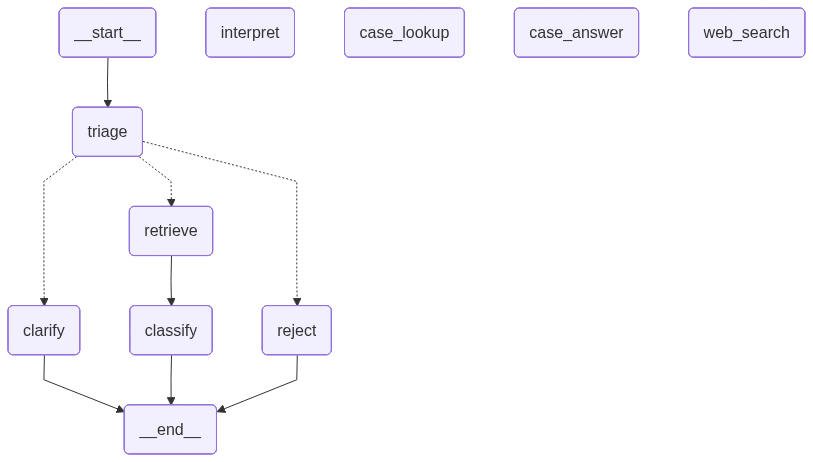

In [36]:
app

### Step 10. 세션 메모리 (최대 3명)
* day14 `ChatSession`처럼 **딕셔너리로 사용자별 대화 이력**을 보관합니다.
* LangGraph checkpointer 없이, 가장 단순한 방식입니다.
* `SESSION_FLAGS`: 직전 응답이 역질문(`clarify`)이면 다음 입력을 `awaiting_clarify`로 처리합니다.


In [37]:
from langchain_core.messages import HumanMessage, AIMessage

MAX_USERS = 3
SESSIONS: dict[str, list] = {}  # {session_id: [HumanMessage, AIMessage, ...]}
# 세션별 역질문 대기 상태
SESSION_FLAGS: dict[str, dict] = {}  # {session_id: {'awaiting_clarify': bool, 'last_clarify': str}}


def get_or_create_session(session_id: str) -> list:
    """session_id에 해당하는 대화 이력을 가져오거나 새로 만듭니다. (최대 3명)"""
    if session_id in SESSIONS:
        return SESSIONS[session_id]

    if len(SESSIONS) >= MAX_USERS:
        raise ValueError(
            f'사용자는 최대 {MAX_USERS}명입니다. 현재: {list(SESSIONS.keys())}'
        )

    SESSIONS[session_id] = []
    SESSION_FLAGS[session_id] = {'awaiting_clarify': False, 'last_clarify': ''}
    print('[session] 생성:', session_id)
    return SESSIONS[session_id]


def _history_to_text(history: list, limit: int = 6) -> str:
    """최근 메시지를 텍스트로 직렬화합니다."""
    bits = []
    for m in history[-limit:]:
        role = '사용자' if isinstance(m, HumanMessage) else 'AI'
        bits.append(f'{role}: {m.content}')
    return '\n'.join(bits)


def ask_agent(session_id: str, question: str) -> str:
    """세션 이력을 붙인 뒤 Graph를 실행하고, 답변을 이력에 저장합니다.

    - 직전 source가 clarify면 이번 입력을 awaiting_clarify=True로 넣어
      triage → retrieve/reject conditional_edges를 다시 탑니다.
    """
    history = get_or_create_session(session_id)
    flags = SESSION_FLAGS.setdefault(
        session_id, {'awaiting_clarify': False, 'last_clarify': ''}
    )
    awaiting = bool(flags.get('awaiting_clarify'))

    history_text = _history_to_text(history)
    if awaiting and flags.get('last_clarify'):
        history_text = (
            history_text
            + ('\n' if history_text else '')
            + f"AI(직전 역질문): {flags['last_clarify']}"
        )

    # RAG/분류에 쓸 질문: 역질문 답변 턴이면 문맥을 질문 문자열에 함께 넣음
    graph_question = question
    if awaiting:
        graph_question = (
            f'사용자 확인/답변: {question}\n'
            f'직전 역질문: {flags.get("last_clarify", "")}\n'
            '위 내용을 이전 도로교통 대화의 이어서 질문으로 해석하세요.'
        )

    result = app.invoke(
        AgentState(
            session_id=session_id,
            question=graph_question,
            history_text=history_text,
            awaiting_clarify=awaiting,
        )
    )
    answer = result['answer'] if isinstance(result, dict) else result.answer
    source = result['source'] if isinstance(result, dict) else result.source

    history.append(HumanMessage(content=question))
    history.append(AIMessage(content=answer))

    if source == 'clarify':
        flags['awaiting_clarify'] = True
        flags['last_clarify'] = answer
    else:
        flags['awaiting_clarify'] = False
        flags['last_clarify'] = ''

    return answer


print('세션 준비 완료. 허용 사용자 수:', MAX_USERS)


세션 준비 완료. 허용 사용자 수: 3


### Step 11. 단발 테스트
* 루프 전에 질문 몇 개로 Graph가 잘 도는지 확인합니다.
* A: 이력 없는 무관 질문 → reject
* B: 법률 관련 질문 → retrieve 경로
* C: 관련 대화 후 모호/무관 입력 → clarify → 다음 답변으로 재분기


In [38]:
# 테스트 전 세션 초기화
SESSIONS.clear()
SESSION_FLAGS.clear()

# 1) 이력 없는 무관 질문 → reject (역질문 불가 기준 1)
print('==== 테스트 A: 이력 없는 무관 질문 ====')
print(ask_agent('user1', '오늘 점심 뭐 먹을까?'))
print()

# 2) 단순/관련 질문
print('==== 테스트 B: 법률 관련 질문 ====')
print(ask_agent('user1', '음주운전하면 어떤 처벌을 받나요?'))
print()

# 3) 문맥 있는 모호 입력 → clarify 기대
print('==== 테스트 C: 문맥 있는 모호 입력 ====')
print(ask_agent('user1', '그거 다시 말해줘'))
print('awaiting_clarify =', SESSION_FLAGS['user1']['awaiting_clarify'])
print()

# 4) 역질문에 대한 답 → conditional_edges 재실행
print('==== 테스트 D: 역질문 답변 ====')
print(ask_agent('user1', '응 음주운전 처벌 기준 알려줘'))


==== 테스트 A: 이력 없는 무관 질문 ====
[session] 생성: user1
[triage] ROUTE=REJECT → reject
[reject] 도로교통법과 관련된 질문만 답변할 수 있어요. 예: 음주운전 처벌, 신호위반 과실, 사고 후 미조치 등
도로교통법과 관련된 질문만 답변할 수 있어요. 예: 음주운전 처벌, 신호위반 과실, 사고 후 미조치 등

==== 테스트 B: 법률 관련 질문 ====
[triage] ROUTE=RETRIEVE → retrieve
[retrieve] hits: 4
  (1) 친 자는 3년 이하의 징역 또는 3천만원 이하의 벌금에 처한다. ② 제50조의3제4항을 위반하여 장치가 해체ㆍ조작되었거나 효용이 떨어진 것을 알 ...
  (2) 법제처                                                            50                ...
  (3) 법제처                                                            45                ...
  (4) 만, 제2항에 따라 음주운전 방지장치가 설치ㆍ등록된 자동차등을 운전하려는 경우에는 그러하지 아니하다. ② 「여객자동차 운수사업법」에 따른 여객자 ...
[classify] CASE → need_case= True
[case_lookup] keywords= ['음주운전', '처벌', '법률', '판례'] | hits= 5
[case_answer] 판례 기반 답변 생성 완료
음주운전은 매우 심각한 범죄로, 법에 따라 다양한 처벌을 받을 수 있습니다. 도로교통법에 따르면, 음주운전으로 적발되면 다음과 같은 처벌을 받을 수 있습니다:

1. **혈중 알코올 농도에 따라 처벌**:
   - 혈중 알코올 농도가 0.2% 이상인 경우: 2년 이상 6년 이하의 징역형 또는 1천만 원 이상 3천만 원 이하의 벌금.
   - 혈중 알코올 농도가 0.03% 이상 0.2% 미만인 경우: 1

### Step 12. `input()` 대화 루프
* 시작할 때 **세션 ID를 한 번** 입력합니다.
* 대화 중 명령어:
  * `사용자변경` → 다른 세션 ID로 전환 (각 세션 history는 그대로 유지)
  * `종료` → 프로그램 종료
* 세션은 `user1` / `user2` / `user3`만 가능합니다.


In [39]:
print('도로교통법 Agent PoC')
print('명령어: 사용자변경 | 종료')
print('세션: user1 / user2 / user3')
print('현재 세션 목록:', list(SESSIONS.keys()) or '(없음)')

# 시작 시 세션 ID를 한 번 입력
session_id = input('세션ID (user1~user3): ').strip() or 'user1'
# 세션을 미리 만들어 두면, 나중에 다시 돌아왔을 때 history가 이어짐
get_or_create_session(session_id)
print(f'세션 "{session_id}" 에서 대화를 시작합니다.\n')

while True:
    question = input(f'[{session_id} 질문]: ').strip()
    if not question:
        continue

    # 종료
    if question == '종료':
        print('종료합니다.')
        break

    # 다른 사용자(세션)로 전환 — SESSIONS에 저장된 history는 유지됨
    if question == '사용자변경':
        new_id = input('새 세션ID (user1~user3): ').strip()
        if not new_id:
            print('세션ID가 비어 있어 변경하지 않습니다.')
            continue
        try:
            get_or_create_session(new_id)  # 새 사용자면 생성, 기존이면 history 재사용
            session_id = new_id
            print(f'세션을 "{session_id}" 로 변경했습니다. (이전 history 유지)\n')
        except ValueError as e:
            print('오류:', e)
        continue

    # 일반 질문
    try:
        answer = ask_agent(session_id, question)
        print(f'\n[사용자] ({session_id})\n{question}\n')
        print(f'[답변] ({session_id})\n{answer}\n')
    except ValueError as e:
        print('오류:', e)



도로교통법 Agent PoC
명령어: 사용자변경 | 종료
세션: user1 / user2 / user3
현재 세션 목록: ['user1']
[session] 생성: ㅇㅇㅇ
세션 "ㅇㅇㅇ" 에서 대화를 시작합니다.

[triage] ROUTE=REJECT → reject
[reject] 도로교통법과 관련된 질문만 답변할 수 있어요. 예: 음주운전 처벌, 신호위반 과실, 사고 후 미조치 등

[사용자] (ㅇㅇㅇ)
내가 뭐라고 했지?

[답변] (ㅇㅇㅇ)
도로교통법과 관련된 질문만 답변할 수 있어요. 예: 음주운전 처벌, 신호위반 과실, 사고 후 미조치 등

[triage] ROUTE=REJECT → reject
[reject] 도로교통법과 관련된 질문만 답변할 수 있어요. 예: 음주운전 처벌, 신호위반 과실, 사고 후 미조치 등

[사용자] (ㅇㅇㅇ)
왜 안나오지

[답변] (ㅇㅇㅇ)
도로교통법과 관련된 질문만 답변할 수 있어요. 예: 음주운전 처벌, 신호위반 과실, 사고 후 미조치 등

[triage] ROUTE=CLARIFY → clarify
[clarify] 상대방이 음주운전으로 인해 문제가 발생한 것에 대해 말씀하시려는 건가요? 예/아니오로 답변해 주실 수 있나요?

[사용자] (ㅇㅇㅇ)
상대가 음주운전이야

[답변] (ㅇㅇㅇ)
상대방이 음주운전으로 인해 문제가 발생한 것에 대해 말씀하시려는 건가요? 예/아니오로 답변해 주실 수 있나요?

[triage/awaiting_clarify] ROUTE=RETRIEVE → retrieve
[retrieve] hits: 4
  (1) 지정한 곳에서는 교차로의 중심 바깥쪽을 통과할 수 있다.<개정 2020. 12. 22.> ③ 제2항에도 불구하고 자전거등의 운전자는 교차로에서  ...
  (2) 니 된다. ⑦ 자전거등의 운전자는 행정안전부령으로 정하는 크기와 구조를 갖추지 아니하여 교통안전에 위험을 초래할 수 있는 자전거등을 운전하여서는 ...
  (3) 법제처                                